In [ ]:
#Project 1 of 5 months projects series
#Thesis ""This project analyzes Beijing’s PM2.5 air quality data to explore the pattern of missing sensor
#readings, revealing that missing data tends to cluster around high-pollution events, and investigates how
#standard imputation methods might lead to misleading conclusions.""

Saving PRSA_data_2010.1.1-2014.12.31.csv to PRSA_data_2010.1.1-2014.12.31.csv
File Uploaded
   No  year  month  day  hour  pm2.5  DEWP  TEMP    PRES cbwd    Iws  Is  Ir
0   1  2010      1    1     0    NaN   -21 -11.0  1021.0   NW   1.79   0   0
1   2  2010      1    1     1    NaN   -21 -12.0  1020.0   NW   4.92   0   0
2   3  2010      1    1     2    NaN   -21 -11.0  1019.0   NW   6.71   0   0
3   4  2010      1    1     3    NaN   -21 -14.0  1019.0   NW   9.84   0   0
4   5  2010      1    1     4    NaN   -20 -12.0  1018.0   NW  12.97   0   0
(43824, 13)
No          0
year        0
month       0
day         0
hour        0
pm2.5    2067
DEWP        0
TEMP        0
PRES        0
cbwd        0
Iws         0
Is          0
Ir          0
dtype: int64


/tmp/ipykernel_2918/3279381273.py:12: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  data["pm2.5_imputed"] = data["pm2.5"].fillna(method = "ffill")


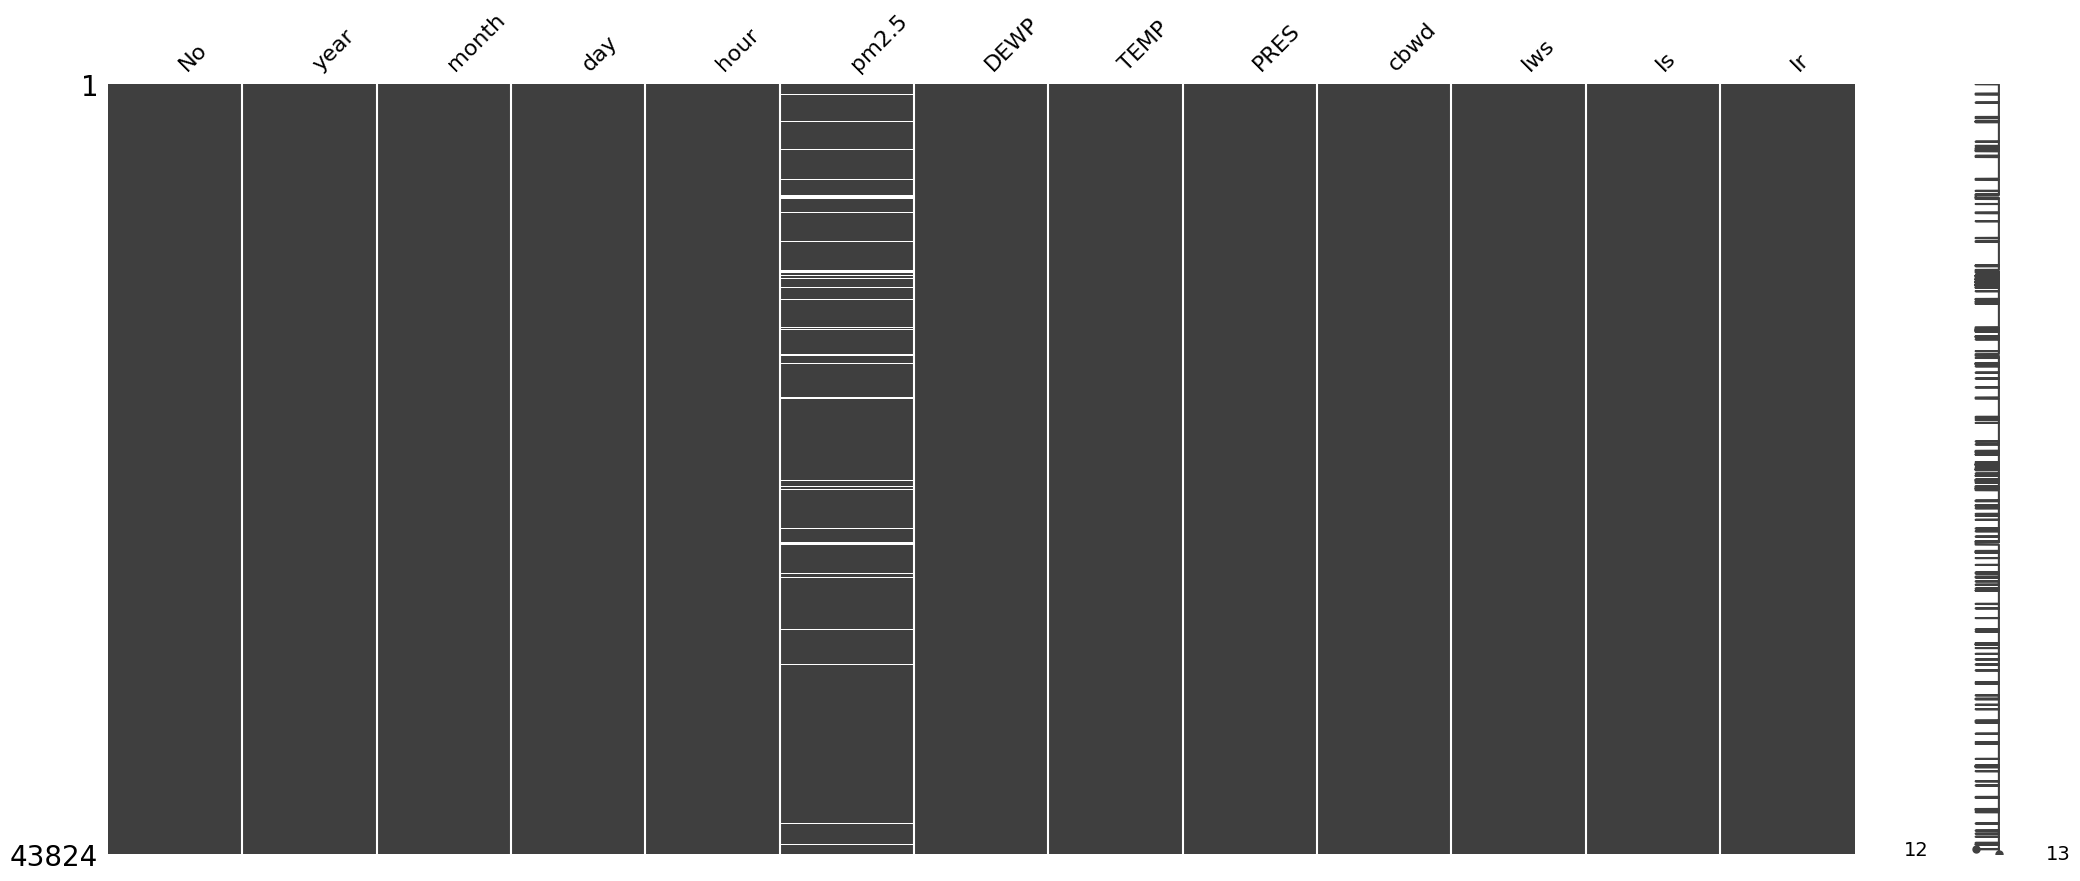

In [ ]:
import pandas as pd
from google.colab import files
uploaded = files.upload()
file_name = list(uploaded.keys())[0]
print("File Uploaded")
data=pd.read_csv(file_name)
print(data.head())
print(data.shape)
print(data.isnull().sum())
import missingno as msno
msno.matrix(data)
data["pm2.5_imputed"] = data["pm2.5"].fillna(method = "ffill")

/tmp/ipykernel_2918/2377942260.py:3: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  data["pm2.5_imputed"] = data["pm2.5"].fillna(method = "ffill")


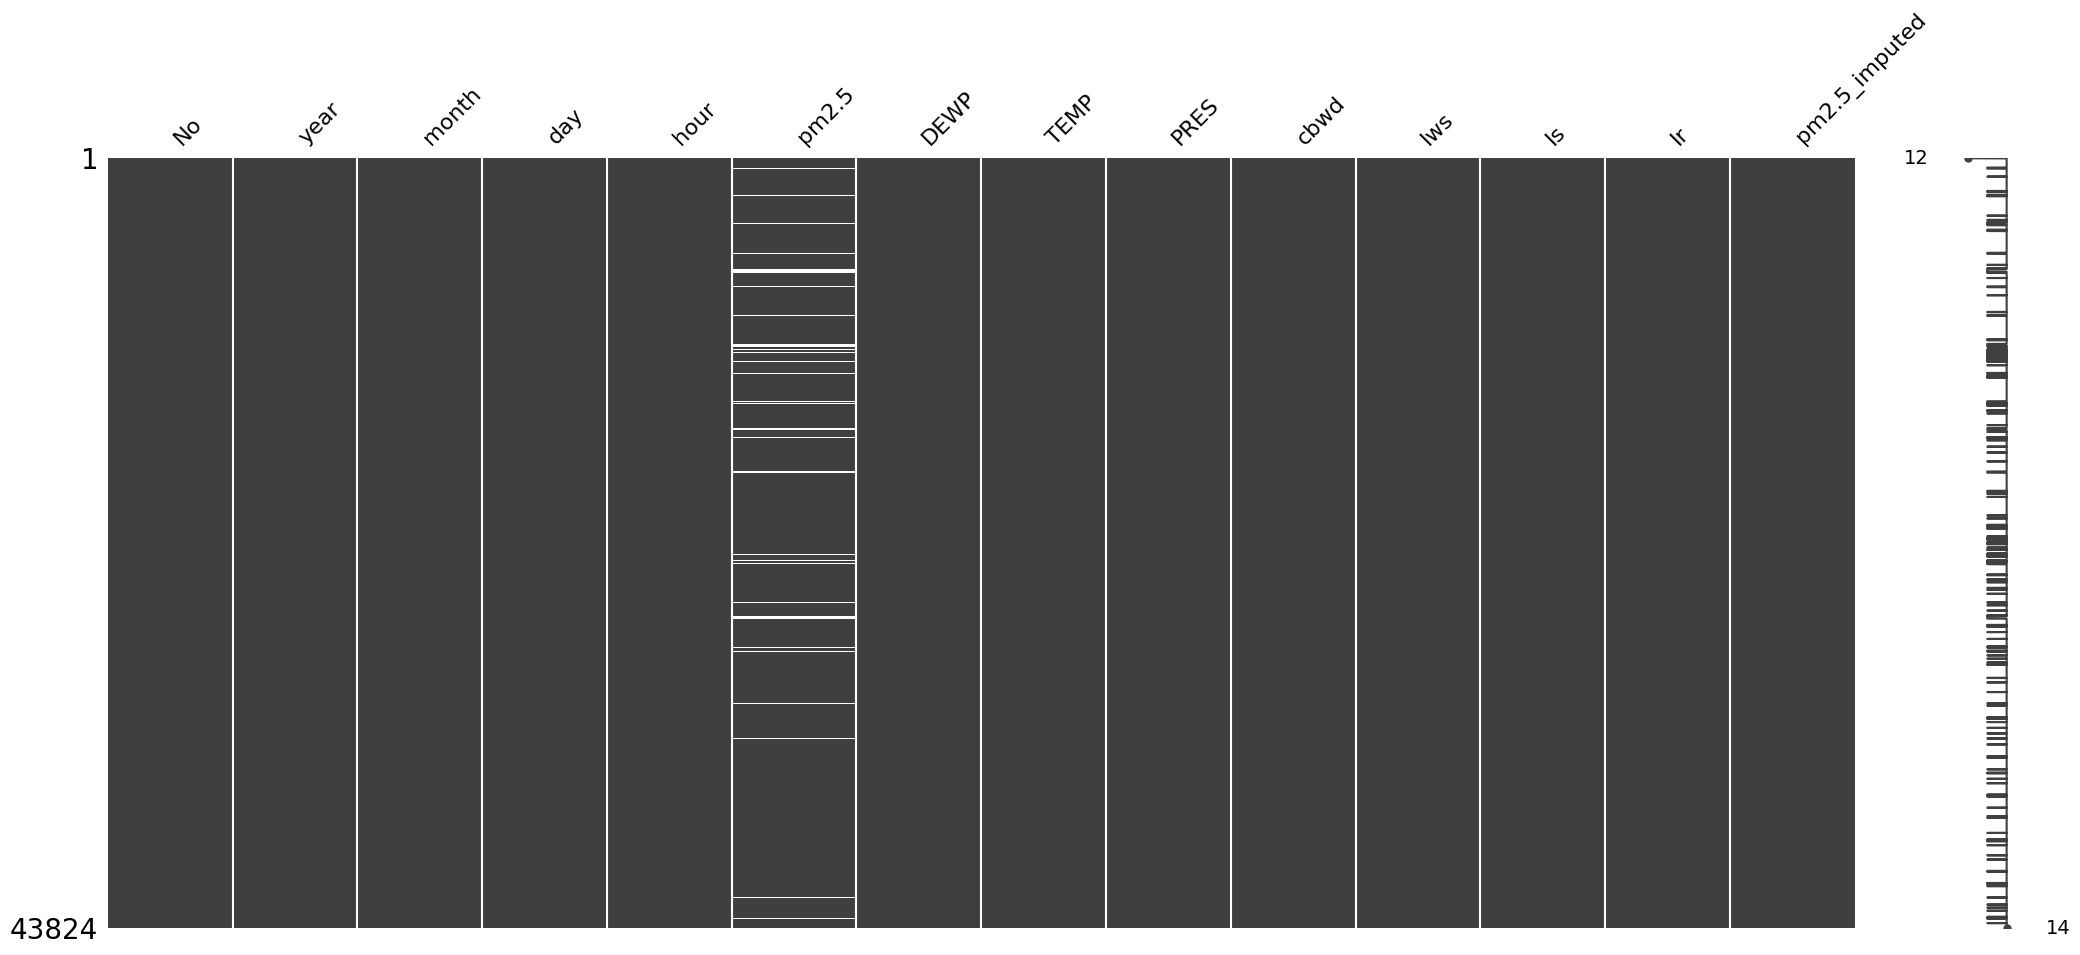

In [ ]:
import missingno as msno
msno.matrix(data)
data["pm2.5_imputed"] = data["pm2.5"].fillna(method = "ffill")

In [ ]:
data["pm2.5_imputed"] = data["pm2.5"].fillna(method = "ffill")

/tmp/ipykernel_2918/2452233755.py:1: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  data["pm2.5_imputed"] = data["pm2.5"].fillna(method = "ffill")


In [ ]:
high_pollution_threshhold = 150
missing_total = data.isnull().sum()
high_polltion_missing_values = data[data["pm2.5"]>high_pollution_threshhold]["pm2.5"].isnull().sum()
print(f"the total number of missing values in our dataset is: {missing_total}")
print(f"the total number of missing values that are clos to higher values in our dataset is: {high_polltion_missing_values}")

the total number of missing values in our dataset is: No                  0
year                0
month               0
day                 0
hour                0
pm2.5            2067
DEWP                0
TEMP                0
PRES                0
cbwd                0
Iws                 0
Is                  0
Ir                  0
pm2.5_imputed      24
dtype: int64
the total number of missing values that are clos to higher values in our dataset is: 0


<function matplotlib.pyplot.show(close=None, block=None)>

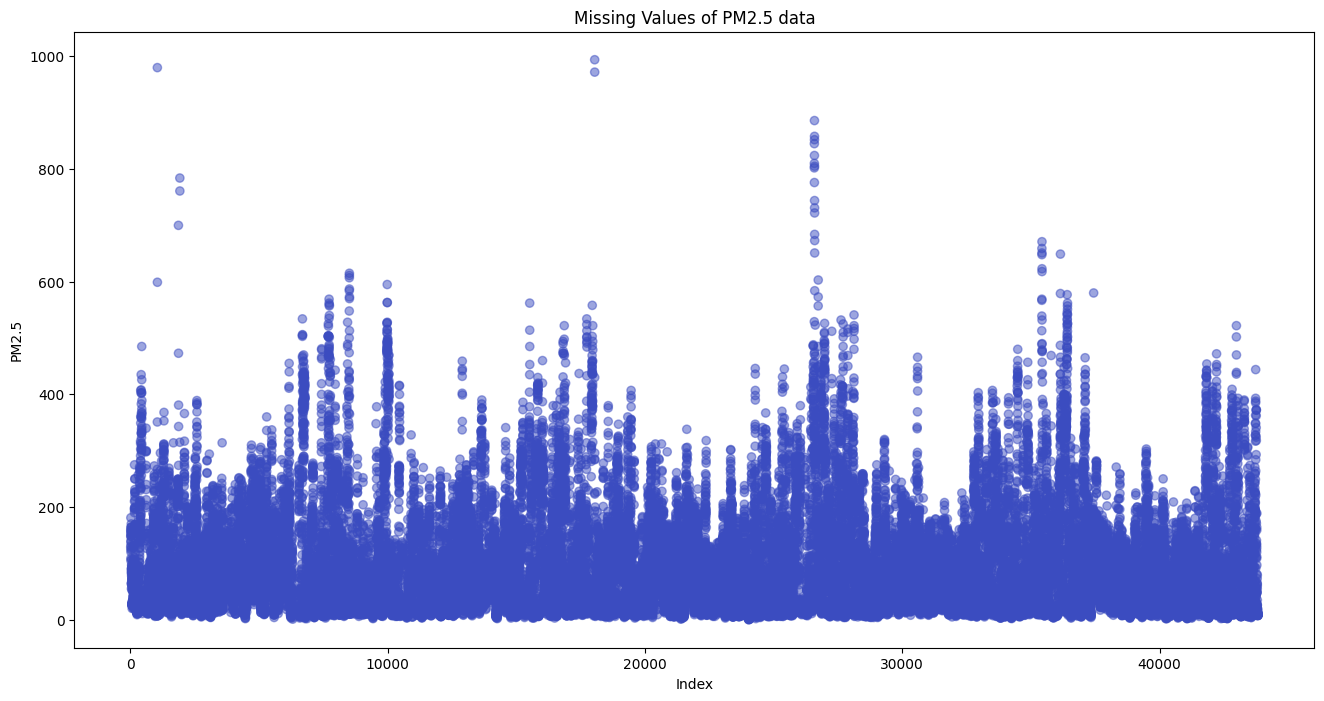

In [ ]:
import matplotlib.pyplot as plt
plt.figure(figsize = (16,8))
plt.scatter(data.index, data["pm2.5"], c=data["pm2.5"].isnull(), cmap = "coolwarm", alpha=0.5)
plt.xlabel("Index")
plt.ylabel("PM2.5")
plt.title("Missing Values of PM2.5 data")
plt.show

In [ ]:
data["pm2.5_imputed"] = data["pm2.5"].fillna(method = "ffill")
data["pm2.5_bfill"] = data["pm2.5"].fillna(method = "bfill")
data["pm2.5_mean"] = data["pm2.5"].fillna(data["pm2.5"].mean())
data["pm2.5_intpolate"] = data["pm2.5"].interpolate()

/tmp/ipykernel_2918/352758122.py:1: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  data["pm2.5_imputed"] = data["pm2.5"].fillna(method = "ffill")
/tmp/ipykernel_2918/352758122.py:2: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  data["pm2.5_bfill"] = data["pm2.5"].fillna(method = "bfill")


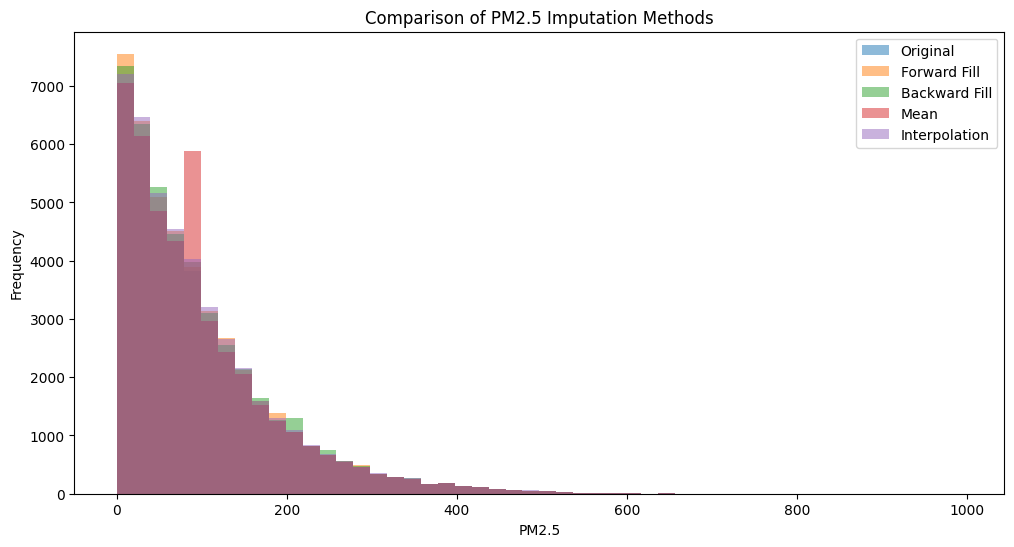

In [ ]:
plt.figure(figsize=(12,6))
plt.hist(data['pm2.5'].dropna(), bins=50, alpha=0.5, label='Original')
plt.hist(data['pm2.5_imputed'], bins=50, alpha=0.5, label='Forward Fill')
plt.hist(data['pm2.5_bfill'], bins=50, alpha=0.5, label='Backward Fill')
plt.hist(data['pm2.5_mean'], bins=50, alpha=0.5, label='Mean')
plt.hist(data["pm2.5_intpolate"], bins=50, alpha=0.5, label='Interpolation')
plt.legend()
plt.xlabel("PM2.5")
plt.ylabel("Frequency")
plt.title("Comparison of PM2.5 Imputation Methods")
plt.show()